In [2]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import keras

In [3]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [4]:
from sklearn.datasets import load_iris

iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['target'] = iris.target
df.sample(5)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
63,6.1,2.9,4.7,1.4,1
67,5.8,2.7,4.1,1.0,1
6,4.6,3.4,1.4,0.3,0
37,4.9,3.6,1.4,0.1,0
133,6.3,2.8,5.1,1.5,2


In [5]:
df.shape

(150, 5)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [7]:
x = df.drop('target',axis=1)
y = df['target']

In [8]:
y.shape



(150,)

In [12]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [13]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(120, 4)
(30, 4)
(120,)
(30,)


In [14]:
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(X_train)
x_test_scaled = scaler.transform(X_test)

#ANN

In [23]:
ann_model = tf.keras.Sequential([
    tf.keras.layers.Dense(8, activation='relu', input_shape=(4,)),
    tf.keras.layers.Dense(4, activation='relu'),
    tf.keras.layers.Dense(3, activation='softmax')
])

In [ ]:
ann_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
ann_history = ann_model.fit(x_train_scaled, y_train, epochs=50,
                    batch_size=10, validation_split=0.2)

In [18]:
ann_loss, ann_accuracy = ann_model.evaluate(x_test_scaled, y_test,verbose=0)
print("Test Accuracy:", ann_accuracy)
print("test loss:", ann_loss)

Test Accuracy: 0.9333333373069763
test loss: 0.2615309953689575


In [19]:
ann_probs = ann_model.predict(x_test_scaled)
print(ann_probs[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
[0.02790787 0.6489214  0.32317078]


In [20]:
predicted_classes = np.argmax(ann_probs, axis=1)
print(predicted_classes)


[1 0 2 1 2 0 1 2 1 1 2 0 0 0 0 2 2 1 1 2 0 2 0 2 2 2 2 2 0 0]


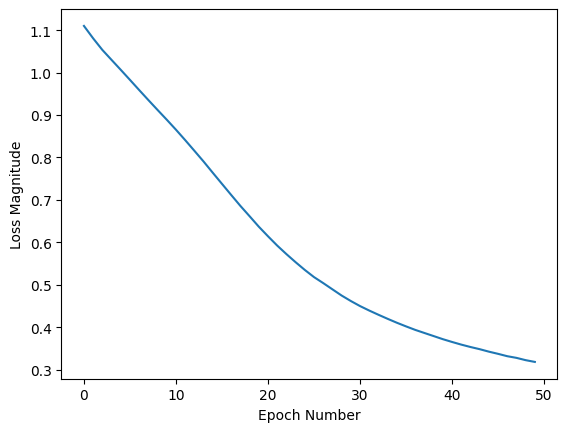

In [21]:
import matplotlib.pyplot as plt
plt.xlabel('Epoch Number')
plt.ylabel("Loss Magnitude")
plt.plot(ann_history.history['loss'])